In [49]:
library(tidyverse)
library(repr)
library(paletteer)
library(ggplot2)

# Data and Rates

In [2]:
tl_raw<- read_csv('/Users/brookesienkiewicz/Documents/sctld/SCTLD_samples/Tissue_Loss/T1-T4_Avg_Tissue_Loss.csv',show_col_types = FALSE)

In [3]:
tl_raw<-tl_raw %>%
    select(1:14) %>%
    select(-`immune_y/n`,-Height,-MaxDiameter,-Size_Class)
# create colony_id
tl_raw<-tl_raw %>%
    mutate(colony_id = paste0("T",TransectNum,"_",Species,'_',NewTagNum))

In [4]:
# combine with colony data for health statuses
colony<-read_csv('/Users/brookesienkiewicz/Documents/sctld/SCTLD_samples/Sample_Data/CBC_ColonyData.csv',show_col_types = FALSE)

In [5]:
colony<-colony %>%
    select(TransectNum,NewTagNum,Species,`062019_Condition`,`102019_Condition`,`052022_Condition`,`122022_Condition`) %>%
    filter(!(TransectNum %in% c('5','6')))
# create colony_id
colony<-colony %>%
    mutate(colony_id = paste0("T",TransectNum,"_",Species,'_',NewTagNum))

In [6]:
head(colony,2)

TransectNum,NewTagNum,Species,062019_Condition,102019_Condition,052022_Condition,122022_Condition,colony_id
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,SSID,Healthy,NA,Diseased,Diseased,T1_SSID_1
1,2,PAST,Healthy,NA,Healthy,Healthy,T1_PAST_2


In [7]:
# merge by colony id 
tl<-tl_raw %>% 
    left_join(colony %>% select(-TransectNum,-NewTagNum,-Species), by = "colony_id")

In [8]:
# select diseased colonies only
conditions <- c('Diseased','Dead')
tl_dis<-tl %>%
    filter(`052022_Condition` %in% conditions | `122022_Condition` %in% conditions)

In [9]:
# pivot
tl_dis_long <- tl_dis %>% 
  pivot_longer(
    cols = matches("^\\d{6}_(Condition|TL)$"),
    names_to = c("Date", ".value"),
    names_pattern = "^(\\d{6})_(Condition|TL)$"
  )

In [10]:
head(tl_dis_long,6)

Date_InitialTag,Transect,TransectNum,NewTagNum,Species,Date_DocumentedDisease,Date_DocumentedMortality,colony_id,Date,TL,Condition
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
6/21/2019,CBC30N,1,1,SSID,5/21/2022,Diseased,T1_SSID_1,062019,82.5,Healthy
6/21/2019,CBC30N,1,1,SSID,5/21/2022,Diseased,T1_SSID_1,052022,37.5,Diseased
6/21/2019,CBC30N,1,1,SSID,5/21/2022,Diseased,T1_SSID_1,122022,25,Diseased
6/21/2019,CBC30N,1,1,SSID,5/21/2022,Diseased,T1_SSID_1,102019,NA,NA
6/21/2019,CBC30N,1,3,SSID,5/21/2022,Diseased,T1_SSID_3,062019,95,Healthy
6/21/2019,CBC30N,1,3,SSID,5/21/2022,Diseased,T1_SSID_3,052022,95,Diseased


In [11]:
# calculate rate of tl for diseased colonies
# change in TL over time
    # collect exact monitoring date
    # calculate number of weeks in between time points
    # calculate change in TL between time points
    # May and Dec: change in TL / number of weeks

In [12]:
# collect exact monitoring date

In [13]:
# add sampling date
samples<-read_csv('/Users/brookesienkiewicz/Documents/sctld/SCTLD_samples/Sample_Data/CBC_samples.csv',show_col_types = FALSE)

In [14]:
samples<-samples %>% 
    select(Month_year,CollectionDate,TransectNum,NewTagNum,Species) %>%
    distinct() %>%
    rename(Date = Month_year) %>%
    mutate(colony_id = paste0("T",TransectNum,"_",Species,'_',NewTagNum))

In [15]:
tld<-tl_dis_long %>% 
    filter(!(is.na(Condition))) %>%
    left_join(samples %>% select(-TransectNum,-NewTagNum,-Species), by = c("colony_id","Date"))

In [16]:
# add in monitoring date
tld<-tld %>%
    mutate(fulldate = as.Date(CollectionDate,format = "%m/%d/%y"))
# if missing collectiondate,
# grab another fulldate from coral with same timepoint
tld <- tld %>%
  group_by(Date, Transect) %>%
  fill(fulldate, .direction = "downup") %>%
  ungroup()

In [17]:
unique(tld$TL)

[1] "82.5"    "37.5"    "25"      "95"      "92.5"    "97.5"    "35"     
 [8] "0"       NA        "27.5"    "100"     "62.5"    "15"      "7.5"    
[15] "5"       "2.5"     "70"      "22.5"    "90"      "65"      "77.5"   
[22] "50"      "52.5"    "exclude" "60"      "55"      "32.5"    "67.5"   
[29] "n/a"     "45"      "20"      "10"      "85"      "40"      "57.5"   
[36] "87.5"

In [18]:
tld$TL <- as.numeric(tld$TL)
# remove NAs (entries were either NA or 'exclude' already)
tld <- tld %>% filter(!(is.na(TL)))

Warning message:
“NAs introduced by coercion”


In [19]:
# drop colonies after they die
# id colonies with 0 tissue twice in a row and remove second time point
tld<- tld %>%
  group_by(colony_id) %>%
  arrange(fulldate, .by_group = TRUE) %>%
  mutate(dead_flag = cummax(as.numeric(TL == 0 & lag(TL, default = first(TL)) == 0))) %>%
  filter(dead_flag == 0) %>%
  select(-dead_flag) %>%
  ungroup()

In [20]:
# calculate number of weeks in between time points
tld <- tld %>%
    group_by(colony_id) %>%
    arrange(fulldate, .by_group = TRUE) %>%
    mutate(diff_weeks = as.numeric(difftime(fulldate, lag(fulldate), units = "weeks"))) %>%
# calculate change in TL between time points
    mutate(diff_tl = TL - lag(TL)) %>%
    ungroup()

In [21]:
# calculate TL rates
tld<-tld %>%
    mutate(rate_abs = round(diff_tl / diff_weeks,2))

In [22]:
# avg TL rates per spp (2019 -> May, May -> Dec)
ratei<-tld %>%
    filter(Date == "052022") %>%
    group_by(Species) %>%
    summarise(mean_rate_abs1 = round(mean(rate_abs, na.rm = TRUE),2)) %>%
    arrange(mean_rate_abs1)

In [23]:
# avg TL rates per spp (May -> Dec)
ratef<-tld %>%
    filter(Date == "122022") %>%
    group_by(Species) %>%
    summarise(mean_rate_abs2 = round(mean(rate_abs, na.rm = TRUE),2)) %>%
    arrange(mean_rate_abs2)

In [24]:
rates_abs<-left_join(ratei,ratef, by = "Species")

In [25]:
# or use percent change as numerator??
# tristin calculated percent change - got csv from his github: https://github.com/TristinH04/TissueLoss/blob/main/testgraphs/PercentAvg/T1-T4_Avg_Tissue_Loss_perchangeboth.csv
perchange<-read_csv("T1-T4_Avg_Tissue_Loss_perchangeboth.csv",show_col_types =  FALSE)

In [26]:
# keep sctld time points only 
pctd <- perchange %>%
    select(TransectNum,NewTagNum,Species,`062019_TL-052022_TL`,`052022_TL-122022_TL`) %>%
    mutate(colony_id = paste0("T",TransectNum,"_",Species,'_',NewTagNum)) %>%
    rename("052022" = `062019_TL-052022_TL`,
          "122022" = `052022_TL-122022_TL`)

In [27]:
# filter colonies
pctd<-pctd %>%
    filter(colony_id %in% unique(tld$colony_id))

In [28]:
# pivot and merge 
pctd<-pctd %>%
    pivot_longer(cols = c('052022','122022'),
                names_to = "Date",
                values_to = "pctd_tl")
tld<-tld %>%
    left_join(pctd%>%select(-TransectNum,-NewTagNum,-Species), by = c('colony_id','Date'))

In [29]:
# calculate rates based on pct change
tld$pctd_tl <- as.numeric(tld$pctd_tl)
tld <- tld %>%   
    mutate(rate_pctd = round(pctd_tl / diff_weeks,2))

Warning message:
“NAs introduced by coercion”


In [30]:
# avg TL rates per spp (2019 -> May, May -> Dec)
ratei<-tld %>%
    filter(Date == "052022") %>%
    group_by(Species) %>%
    summarise(mean_rate_pctd1 = round(mean(rate_pctd, na.rm = TRUE),2))

# avg TL rates per spp (May -> Dec)
ratef<-tld %>%
    filter(Date == "122022") %>%
    group_by(Species) %>%
    summarise(mean_rate_pctd2 = round(mean(rate_pctd, na.rm = TRUE),2))

rates_pctd<-left_join(ratei,ratef, by = "Species")

In [31]:
rates<-left_join(rates_abs,rates_pctd,by = "Species")
rates
# 1 is 2019 - May 2022
# 2 is May 2022 -> Dec 2022

Species,mean_rate_abs1,mean_rate_abs2,mean_rate_pctd1,mean_rate_pctd2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
MMEA,-0.65,NA,-0.66,NA
MCAV,-0.49,-1.08,-0.50,-2.80
PSTR,-0.48,-1.63,-0.50,-21.49
SSID,-0.31,-0.33,-0.32,-0.74
PAST,-0.27,-0.32,-0.28,-34.43
DLAB,NaN,-0.18,NaN,-0.19
OANN,NaN,-0.09,NaN,-8.84
OFAV,NaN,-0.36,NaN,-0.36


In [32]:
# ok i think it makes more sense to compare rates from May -> Dec 2022 
    #since we don't know when outbreak occurred within the first time frame
# maybe can just compare avg tissue loss between species across initial time frame 
    # and then compare rates may -> dec?


In [33]:
# remove rates from initial timeframe and run ANOVA
    # idk if its better to use pct change or abs rates
    # i would think % change would standardize for initial differences in tissue loss but idk if this makes sense mathematically

### Assess Normality 

In [70]:
tld2 %>%
    group_by(Species) %>%
    summarise(n = length(unique(colony_id)))

Species,n
<chr>,<int>
MCAV,15
MMEA,9
PAST,5
PSTR,16
SSID,22


In [71]:
# remove 2019 from og df
tld2 <- tld %>% filter(!(Date %in% c('062019','102019')))
# remove any colonies with NA rates
tld2<-tld2 %>%
    filter(!(is.na(diff_tl)))

# remove low occurance spp 
tl_stats<-tld2 %>%
    group_by(Species) %>%
    # filter low occurance species
    filter(n() >= 3) %>%
    ungroup()

In [72]:
summary(tl_stats$rate_abs)
summary(tl_stats$rate_pctd)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-3.5700 -0.6500 -0.4500 -0.5394 -0.1800  0.4500 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-170.510   -0.660   -0.650   -3.706   -0.240    0.690 

In [73]:
# test for normality of response variable (rates)
shapiro.test(tl_stats$rate_abs)
# not normal


	Shapiro-Wilk normality test

data:  tl_stats$rate_abs
W = 0.74598, p-value = 3.449e-12


In [74]:
# install.packages("rstatix")
# install.packages("ggpubr")
library(rstatix)
# library(ggpubr)

In [75]:
# per group?
tl_stats %>%
    group_by(Species) %>%
    rstatix::shapiro_test(rate_abs) %>%
    filter(p < 0.05)
# non normal

Species,variable,statistic,p
<chr>,<chr>,<dbl>,<dbl>
MCAV,rate_abs,0.7478426,6.254932e-05
MMEA,rate_abs,0.7709570,9.474932e-03
PAST,rate_abs,0.7959458,1.294312e-02
PSTR,rate_abs,0.7061470,1.683673e-05
SSID,rate_abs,0.7651106,1.369733e-06


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


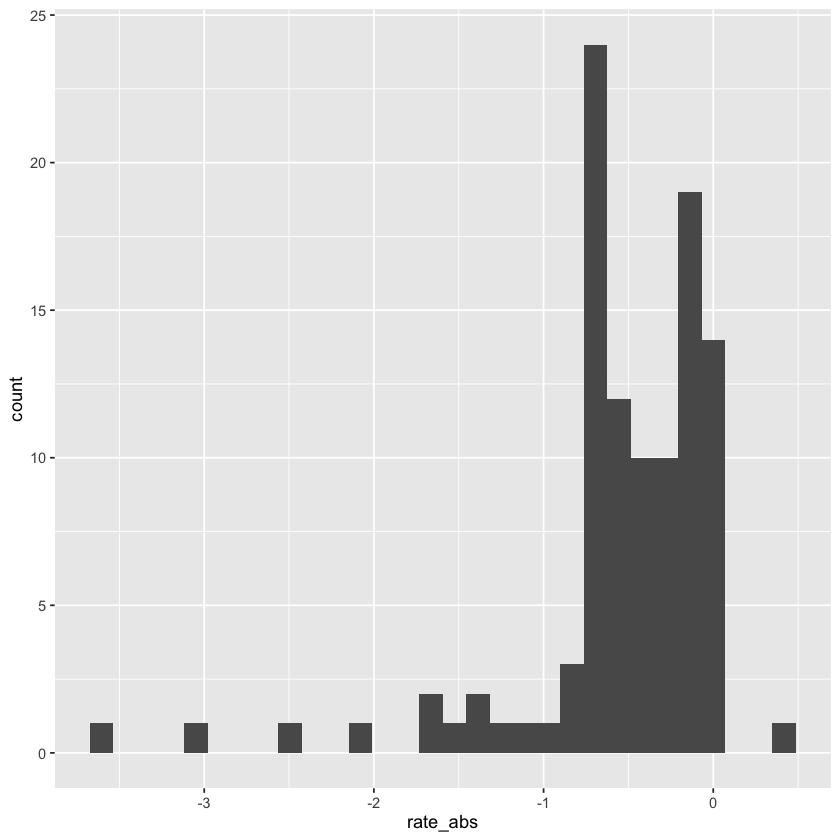

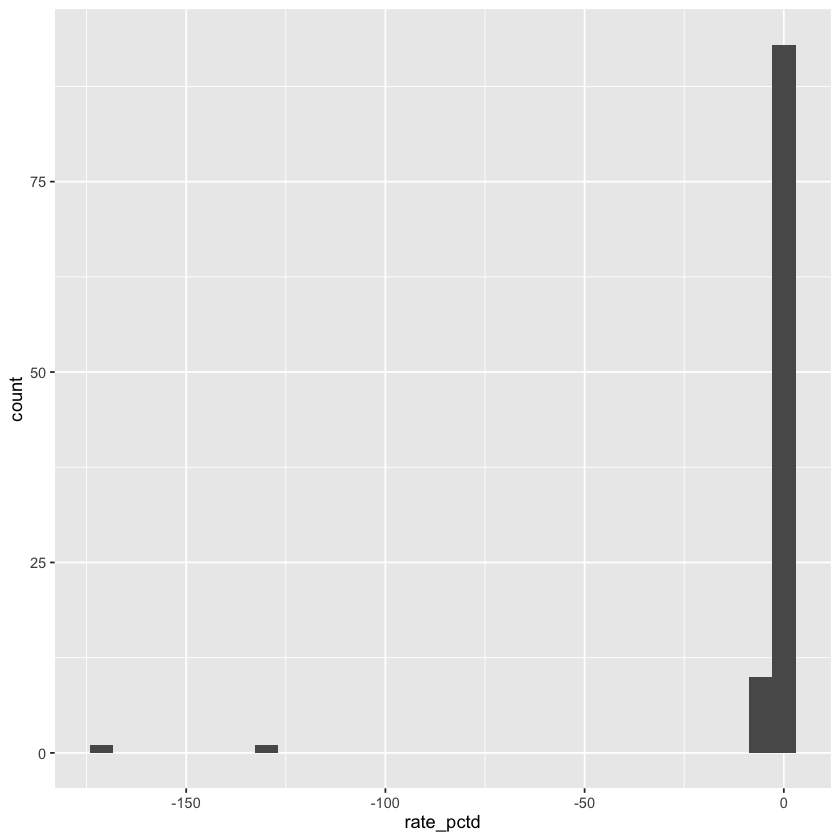

In [78]:
ggplot(tl_stats, aes(x = rate_abs))+
    geom_histogram()
ggplot(tl_stats, aes(x = rate_pctd))+
    geom_histogram()

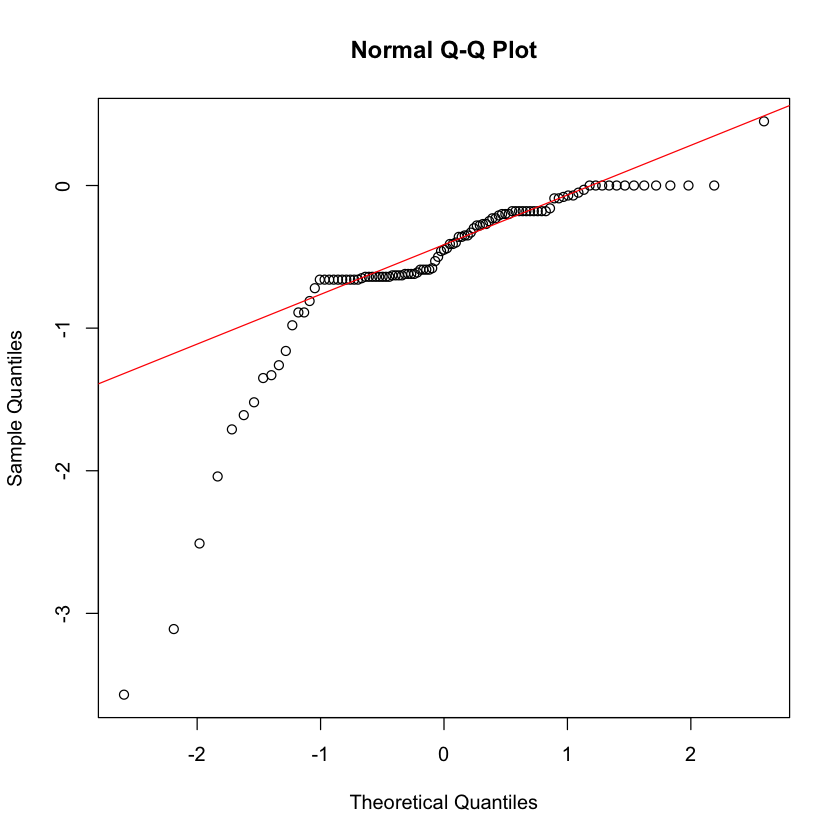

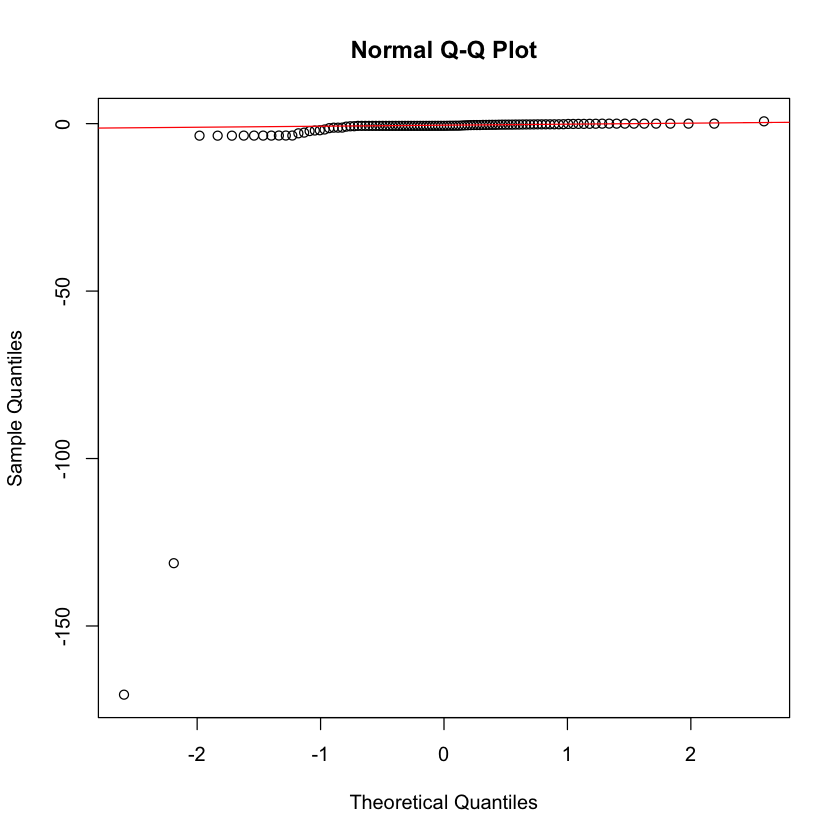

In [80]:
qqnorm(tl_stats$rate_abs)
qqline(tl_stats$rate_abs, col = "red")

qqnorm(tl_stats$rate_pctd)
qqline(tl_stats$rate_pctd, col = "red")

In [ ]:
# non normal

## Stats

In [ ]:
# log transform? or use kruskall wallis or glmm instead of anova?? 

In [86]:
head(tl_stats,3)

Date_InitialTag,Transect,TransectNum,NewTagNum,Species,Date_DocumentedDisease,Date_DocumentedMortality,colony_id,Date,TL,Condition,CollectionDate,fulldate,diff_weeks,diff_tl,rate_abs,pctd_tl,rate_pctd
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6/24/2019,CBC30N,1,14,MCAV,5/21/2022,12/2/2022,T1_MCAV_14,052022,70.0,Diseased,05/21/22,2022-05-21,151.71429,-25,-0.16,-26.31579,-0.17
6/24/2019,CBC30N,1,14,MCAV,5/21/2022,12/2/2022,T1_MCAV_14,122022,0.0,Dead,NA,2022-12-02,27.85714,-70,-2.51,-100.00000,-3.59
6/26/2019,CBC30N,1,15,MCAV,5/21/2022,12/2/2022,T1_MCAV_15,052022,22.5,Diseased,05/21/22,2022-05-21,151.42857,-75,-0.50,-76.92308,-0.51


In [ ]:
# just use dec 2022 for rates

In [87]:
tl_dec<-tl_stats %>% filter(Date == "122022")

In [90]:
# absolute rates
tl_dec %>%
    kruskal_test(rate_abs ~ Species) %>%
    mutate(sig = if_else(p<0.05,'YES','NO'))

tl_dec %>%
  dunn_test(rate_abs ~ Species, p.adjust.method = "bonferroni")

.y.,n,statistic,df,p,method,sig
<chr>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>
rate_abs,40,10.97747,3,0.01184832,Kruskal-Wallis,YES


,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,rate_abs,MCAV,PAST,8,5,1.8899215,0.058768465,0.3526108,ns
2,rate_abs,MCAV,PSTR,8,7,-0.4190993,0.675143554,1.0000000,ns
3,rate_abs,MCAV,SSID,8,20,2.2500357,0.024446679,0.1466801,ns
4,rate_abs,PAST,PSTR,5,7,-2.2104816,0.027071755,0.1624305,ns
5,rate_abs,PAST,SSID,5,20,-0.2723271,0.785370541,1.0000000,ns
6,rate_abs,PSTR,SSID,7,20,2.6372508,0.008358101,0.0501486,ns


In [91]:
# relative rates
tl_dec %>%
    kruskal_test(rate_pctd ~ Species) %>%
    mutate(sig = if_else(p<0.05,'YES','NO'))

tl_dec %>%
  dunn_test(rate_pctd ~ Species, p.adjust.method = "bonferroni")

.y.,n,statistic,df,p,method,sig
<chr>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>
rate_pctd,40,19.34201,3,0.0002323018,Kruskal-Wallis,YES


,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,rate_pctd,MCAV,PAST,8,5,1.6387427,0.1012668664,0.607601199,ns
2,rate_pctd,MCAV,PSTR,8,7,-0.6032766,0.5463247108,1.000000000,ns
3,rate_pctd,MCAV,SSID,8,20,3.1859379,0.0014428555,0.008657133,**
4,rate_pctd,PAST,PSTR,5,7,-2.1287226,0.0332772150,0.199663290,ns
5,rate_pctd,PAST,SSID,5,20,0.7970928,0.4253971342,1.000000000,ns
6,rate_pctd,PSTR,SSID,7,20,3.7458269,0.0001798005,0.001078803,**
